In [2]:
# ==============================================================================
# A.1. Импорт библиотек и загрузка обработанного датасета
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем стиль для графиков
sns.set_style("whitegrid")
print("Библиотеки успешно импортированы.")

# --- Загрузка данных ---
# [Важно!] Убедитесь, что путь к файлу указан верно.
# Скрипт сохранял его в 'data/processed/'. Ноутбук находится в 'notebooks/'.
# Значит, относительный путь будет '../data/processed/featured_dataset.csv'
featured_data_path = '../data/processed/featured_dataset.csv'

try:
    df_featured = pd.read_csv(featured_data_path)
    print(f"Обработанный датасет успешно загружен. Путь: '{featured_data_path}'")

except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{featured_data_path}'.")
    print("Пожалуйста, убедитесь, что вы запустили скрипт предобработки, и проверьте путь.")
    df_featured = None

Библиотеки успешно импортированы.
Обработанный датасет успешно загружен. Путь: '../data/processed/featured_dataset.csv'


In [3]:
# ==============================================================================
# A.2. Общая информация и проверка структуры
# ==============================================================================
if df_featured is not None:
    print("--- Общая информация о датасете ---")
    print(f"Форма датасета (строки, колонки): {df_featured.shape}")
    print("\n--- Типы данных ---")
    print(df_featured.dtypes.value_counts())
    
    print("\n--- Первые 5 строк датасета ---")
    display(df_featured.head())
    
    # Подсчет количества созданных признаков
    original_cols = ['id', 'date', 'E_mu_Z', 'E_mu_X', 'E_nu1_X', 'E_nu2_X', 
                     'E_nu1_Z', 'E_nu2_Z', 'N_mu_X', 'M_mu_XX', 'M_mu_XZ', 
                     'M_mu_X', 'N_mu_Z', 'M_mu_ZZ', 'M_mu_Z', 'N_nu1_X', 
                     'M_nu1_XX', 'M_nu1_XZ', 'M_nu1_X', 'N_nu1_Z', 'M_nu1_ZZ', 
                     'M_nu1_Z', 'N_nu2_X', 'M_nu2_XX', 'M_nu2_XZ', 'M_nu2_X', 
                     'N_nu2_Z', 'M_nu2_ZZ', 'M_nu2_Z', 'bayesImVoltage', 
                     'synErr', 'N_EC_rounds', 'maintenance_flag', 'E_mu_Z_est', 
                     'R', 's', 'p']
    
    num_generated_features = df_featured.shape[1] - len(original_cols)
    print(f"\nБыло сгенерировано примерно {num_generated_features} новых признаков.")

--- Общая информация о датасете ---
Форма датасета (строки, колонки): (328616, 693)

--- Типы данных ---
float64    682
int64       11
Name: count, dtype: int64

--- Первые 5 строк датасета ---


,id,date,E_mu_Z,E_mu_X,E_nu1_X,E_nu2_X,E_nu1_Z,E_nu2_Z,N_mu_X,M_mu_XX,...,opticalPower_max_per_id,opticalPower_min_per_id,opticalPower_norm_by_id_mean,opticalPower_dist_from_id_mean,s_mean_per_id,s_std_per_id,s_max_per_id,s_min_per_id,s_norm_by_id_mean,s_dist_from_id_mean
0,553405,0,0.01949,0.04331,0.08333,1.0,0.03499,0.44706,6317804.0,531.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,0.960985,-152.24812
1,553405,1,0.01989,0.02814,0.00000,0.0,0.04234,0.45679,6322055.0,533.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.011724,45.75188
2,553405,2,0.01923,0.03436,0.00000,0.0,0.03534,0.38462,6320564.0,553.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.051189,199.75188
3,553405,3,0.01776,0.02970,0.04000,0.0,0.04264,0.38095,6322326.0,505.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.067333,262.75188
4,553405,4,0.01750,0.02829,0.04000,0.5,0.05015,0.45238,6319264.0,601.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.055289,215.75188



Было сгенерировано примерно 656 новых признаков.


--- Анализ распределений ключевых признаков ---


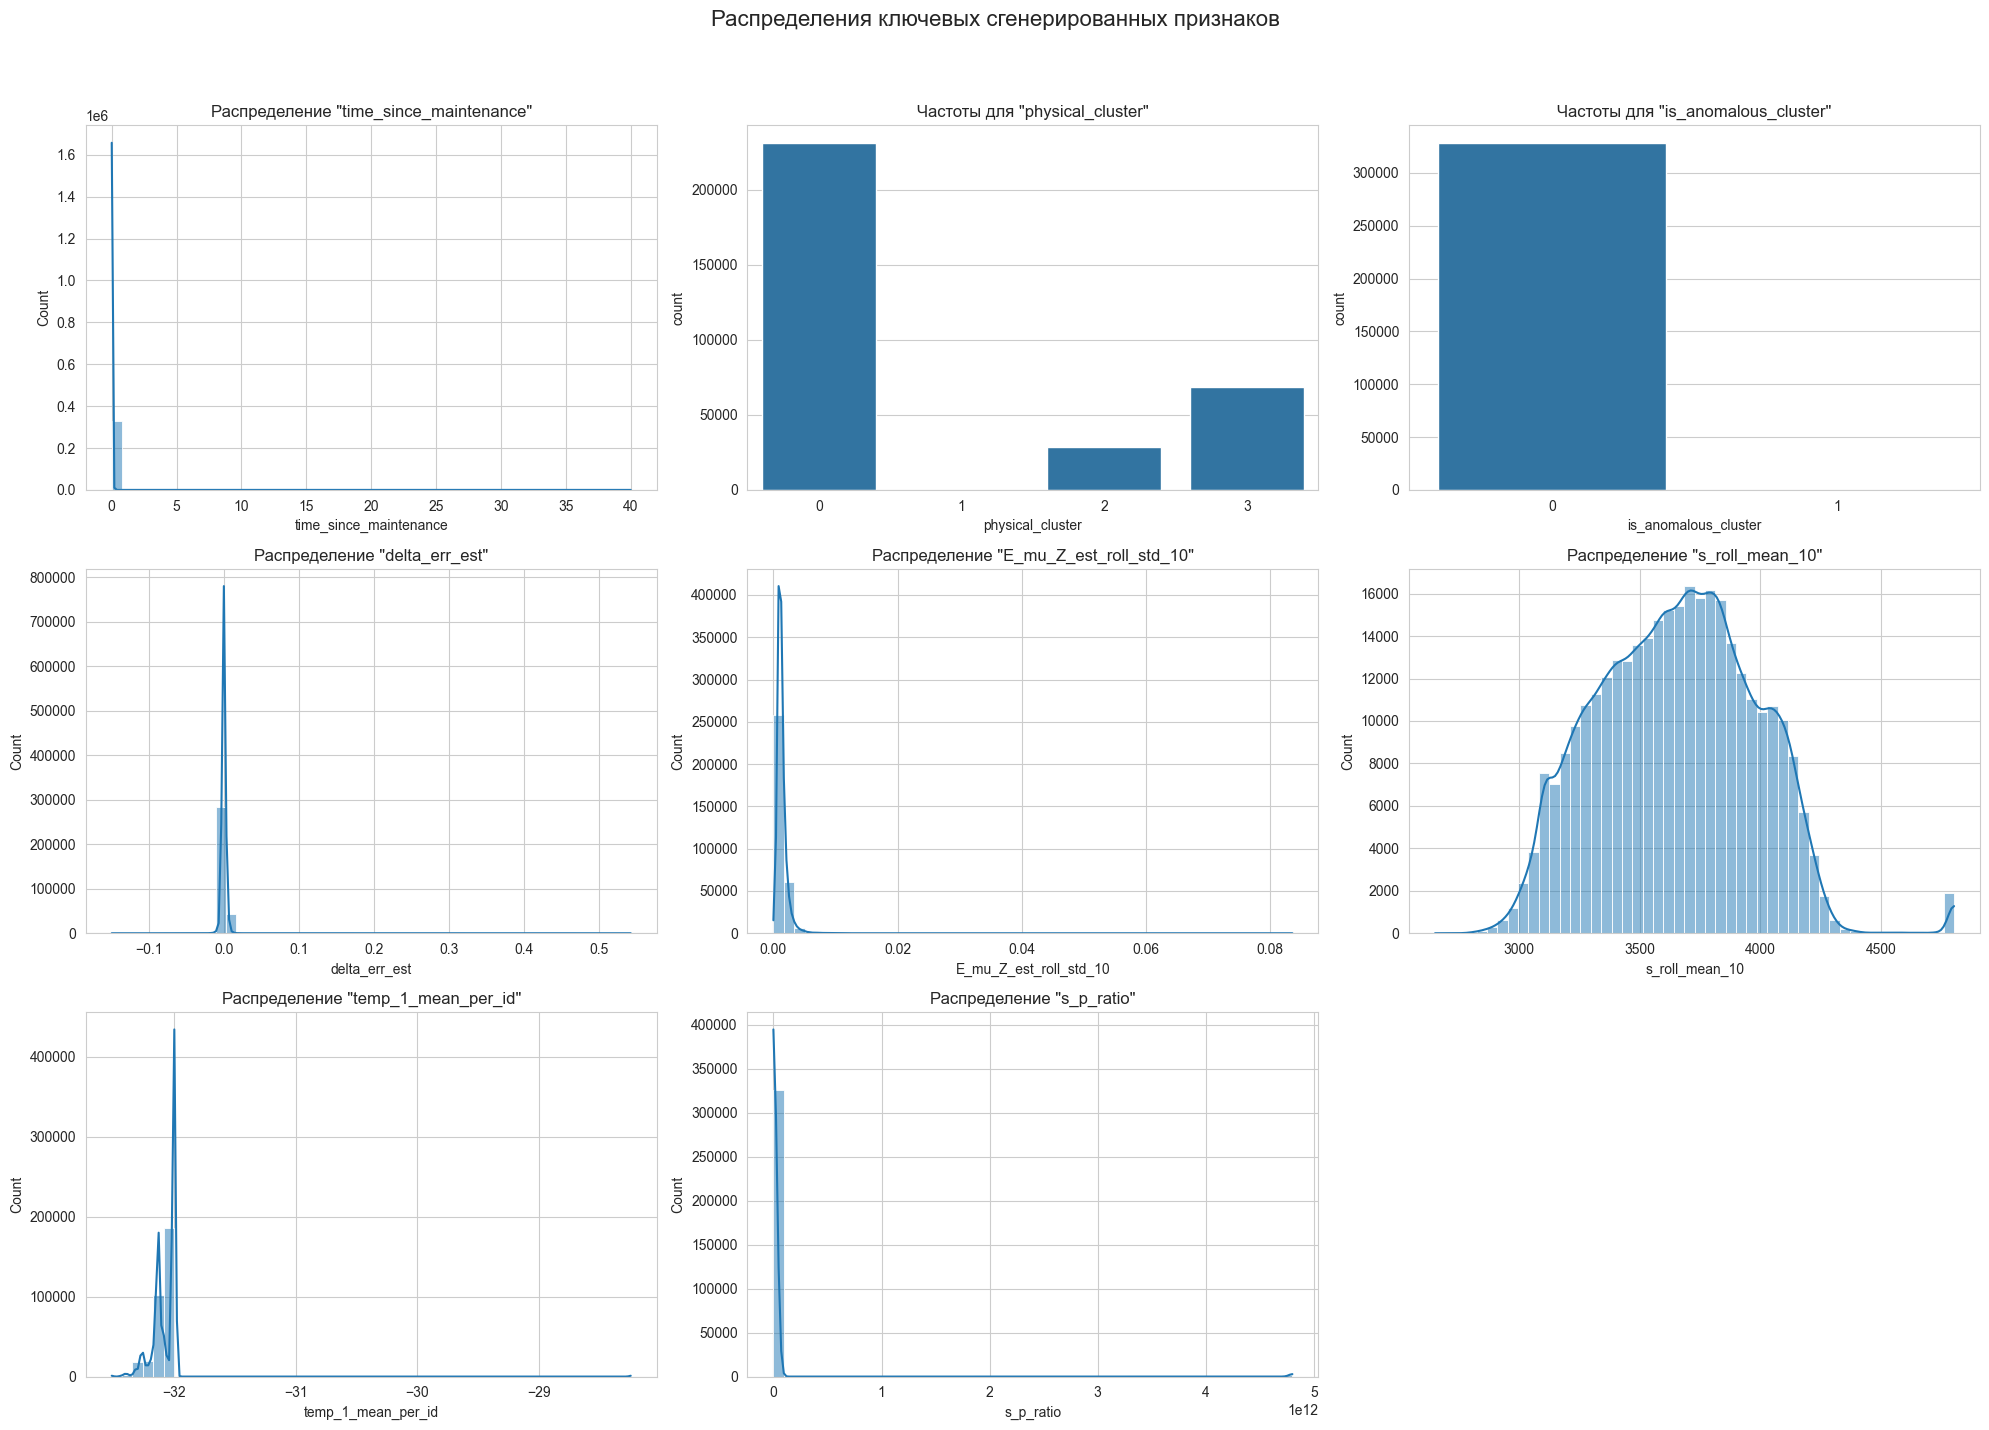


--- Описательные статистики для этих признаков ---


,count,mean,std,min,25%,50%,75%,max
time_since_maintenance,328616.0,3.406712e-02,8.004336e-01,0.000000,0.000000,0.000000,0.000000,4.000000e+01
physical_cluster,328616.0,7.991181e-01,1.258179e+00,0.000000,0.000000,0.000000,2.000000,3.000000e+00
is_anomalous_cluster,328616.0,1.521533e-04,1.233412e-02,0.000000,0.000000,0.000000,0.000000,1.000000e+00
delta_err_est,328616.0,-9.980768e-06,3.327574e-03,-0.149170,-0.001620,-0.000180,0.001510,5.418200e-01
E_mu_Z_est_roll_std_10,327793.0,1.346264e-03,1.126734e-03,0.000000,0.000871,0.001159,0.001568,8.362837e-02
s_roll_mean_10,328616.0,3.650857e+03,3.202232e+02,2655.000000,3407.100000,3658.200000,3882.200000,4.800000e+03
temp_1_mean_per_id,328616.0,-3.206881e+01,1.609160e-01,-32.511548,-32.132370,-32.008224,-32.000000,-2.824584e+01
s_p_ratio,328616.0,3.385836e+10,4.017141e+11,1.081526,1.787456,3.678363,6.754443,4.800000e+12


In [4]:
# ==============================================================================
# A.3. Анализ распределений ключевых сгенерированных признаков
# ==============================================================================
if df_featured is not None:
    key_generated_features = [
        'time_since_maintenance',
        'physical_cluster',
        'is_anomalous_cluster',
        'delta_err_est',
        'E_mu_Z_est_roll_std_10', # Пример волатильности
        's_roll_mean_10',         # Пример сглаживания
        'temp_1_mean_per_id',     # Пример агрегата по сессии
        's_p_ratio'
    ]

    print("--- Анализ распределений ключевых признаков ---")
    
    plt.figure(figsize=(20, 15))
    plt.suptitle("Распределения ключевых сгенерированных признаков", fontsize=16)

    for i, col in enumerate(key_generated_features, 1):
        plt.subplot(3, 3, i)
        if df_featured[col].nunique() > 20: # Гистограмма для непрерывных
            sns.histplot(df_featured[col], kde=True, bins=50)
            plt.title(f'Распределение "{col}"')
        else: # Countplot для категориальных/дискретных
            sns.countplot(x=df_featured[col])
            plt.title(f'Частоты для "{col}"')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n--- Описательные статистики для этих признаков ---")
    display(df_featured[key_generated_features].describe().T)

--- Топ-20 признаков по корреляции Пирсона с 'E_mu_Z' ---


E_mu_Z                              1.000000
E_mu_Z_est                          0.958998
inter_temp_2_x_E_mu_Z_est           0.952439
inter_biasVoltage_2_x_E_mu_Z_est    0.952439
inter_biasVoltage_1_x_E_mu_Z_est    0.952439
inter_temp_1_x_E_mu_Z_est           0.952302
E_mu_Z_est_roll_min_10              0.952227
E_mu_Z_est_ewm_5                    0.950095
E_mu_Z_est_roll_mean_10             0.950055
E_mu_Z_est_roll_min_5               0.945732
E_mu_Z_est_roll_mean_5              0.942379
E_mu_Z_est_lag_1                    0.941876
E_mu_Z_est_mean_per_id              0.939372
E_mu_Z_est_roll_max_5               0.937714
E_mu_Z_est_roll_max_10              0.936397
E_mu_Z_est_lag_5                    0.931420
E_mu_Z_est_lag_2                    0.930952
E_mu_Z_est_lag_3                    0.926284
E_mu_Z_est_min_per_id               0.915284
R                                   0.854933
inter_opticalPower_x_E_mu_Z_est     0.807189
Name: E_mu_Z, dtype: float64


--- Топ-20 признаков по корреляции Пирсона с 'N_EC_rounds' ---


N_EC_rounds                 1.000000
delta_err_est               0.568017
E_mu_Z_est_diff             0.360978
E_mu_X_norm_by_id_mean      0.202947
E_nu1_Z                     0.161606
s_mean_per_id               0.155081
E_mu_X_dist_from_id_mean    0.120770
E_mu_Z                      0.113441
s_roll_max_10               0.112800
E_mu_Z_est_lag_2            0.101825
E_mu_Z_est_lag_3            0.101500
s                           0.095974
p                           0.095974
s_max_per_id                0.093604
s_roll_mean_10              0.088479
E_nu1_Z_lag_5               0.086863
E_mu_Z_est_roll_mean_5      0.085344
E_mu_Z_est_lag_1            0.084559
E_nu1_Z_diff                0.083220
E_mu_Z_est_roll_max_5       0.078213
E_mu_Z_est_roll_min_5       0.077550
Name: N_EC_rounds, dtype: float64

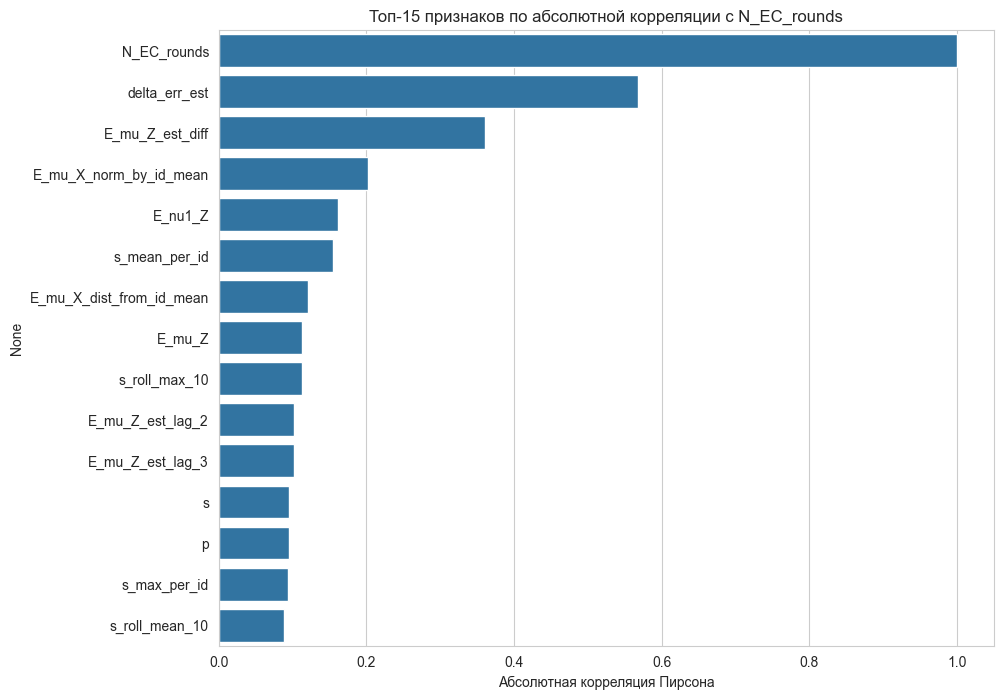

In [5]:
# ==============================================================================
# A.4. Корреляционный анализ с целевыми переменными
# ==============================================================================
if df_featured is not None:
    # Цель для Модели 1: предсказание истинного QBER
    target_1 = 'E_mu_Z'
    # Цель для Модели 2 (Суррогатной): предсказание эффективности
    target_2 = 'N_EC_rounds'
    
    print(f"--- Топ-20 признаков по корреляции Пирсона с '{target_1}' ---")
    corr_target_1 = df_featured.corr(numeric_only=True)[target_1].abs().sort_values(ascending=False)
    display(corr_target_1.head(21)) # 21, чтобы исключить сам таргет

    print(f"\n--- Топ-20 признаков по корреляции Пирсона с '{target_2}' ---")
    corr_target_2 = df_featured.corr(numeric_only=True)[target_2].abs().sort_values(ascending=False)
    display(corr_target_2.head(21)) # 21, чтобы исключить сам таргет

    # Визуализация
    top_features_target_2 = corr_target_2.head(15).index
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=corr_target_2.head(15).values, y=top_features_target_2)
    plt.title(f'Топ-15 признаков по абсолютной корреляции с {target_2}')
    plt.xlabel('Абсолютная корреляция Пирсона')
    plt.show()

--- Анализ пропусков ---
Общее количество ячеек: 227730888
Общее количество пропусков (NaN): 495446
Процент пропущенных данных: 0.22%

--- Матрица пропусков (для первых 100 признаков) ---


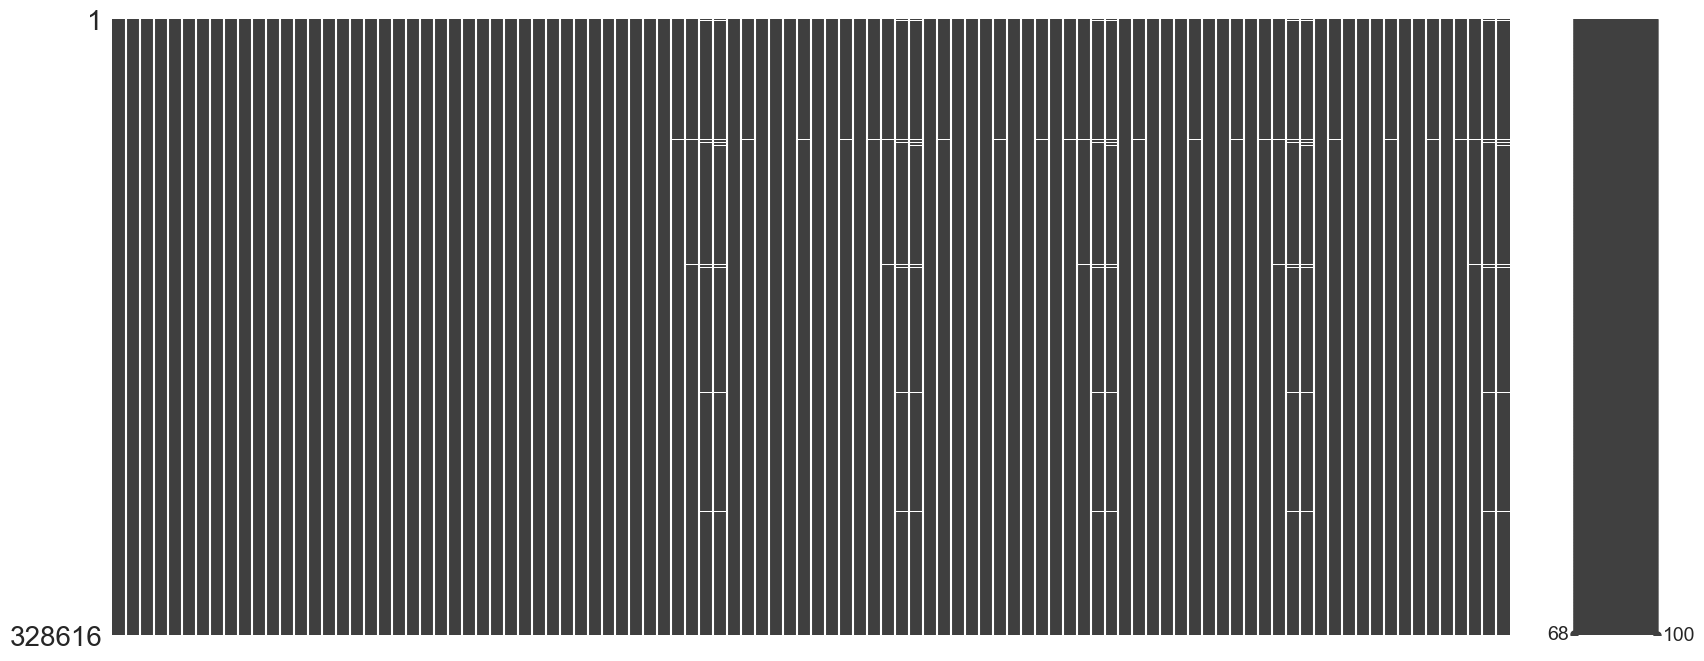


--- Топ-15 признаков по количеству пропусков ---


N_nu2_X_lag_5                   4115
M_nu2_X_lag_5                   4115
E_mu_X_lag_5                    4115
N_nu2_Z_lag_5                   4115
time_since_maintenance_lag_5    4115
M_nu1_ZZ_lag_5                  4115
M_nu1_X_lag_5                   4115
M_nu2_Z_lag_5                   4115
M_nu2_ZZ_lag_5                  4115
N_nu1_Z_lag_5                   4115
polarizerVoltages[2]_lag_5      4115
N_mu_Z_lag_5                    4115
polarizerVoltages[1]_lag_5      4115
M_mu_ZZ_lag_5                   4115
bayesImVoltage_lag_5            4115
dtype: int64

In [7]:
# ==============================================================================
# A.5. Анализ пропусков (NaN)
# ==============================================================================
if df_featured is not None:
    # Исправленный расчет: используем базовое умножение
    total_cells = df_featured.shape[0] * df_featured.shape[1]
    total_missing = df_featured.isnull().sum().sum()
    percent_missing = (total_missing / total_cells) * 100

    print(f"--- Анализ пропусков ---")
    print(f"Общее количество ячеек: {total_cells}")
    print(f"Общее количество пропусков (NaN): {total_missing}")
    print(f"Процент пропущенных данных: {percent_missing:.2f}%")

    # Визуализация матрицы пропусков для первых 100 признаков
    try:
        import missingno as msno
        print("\n--- Матрица пропусков (для первых 100 признаков) ---")
        msno.matrix(df_featured.iloc[:, :100], figsize=(20, 8))
        plt.show()
    except ImportError:
        print("\nБиблиотека 'missingno' не установлена. Пропустите визуализацию матрицы.")
        print("Для установки выполните: pip install missingno")

    print("\n--- Топ-15 признаков по количеству пропусков ---")
    missing_counts = df_featured.isnull().sum().sort_values(ascending=False)
    display(missing_counts.head(15))

--- Анализ распределения ключевых сгенерированных признаков ---


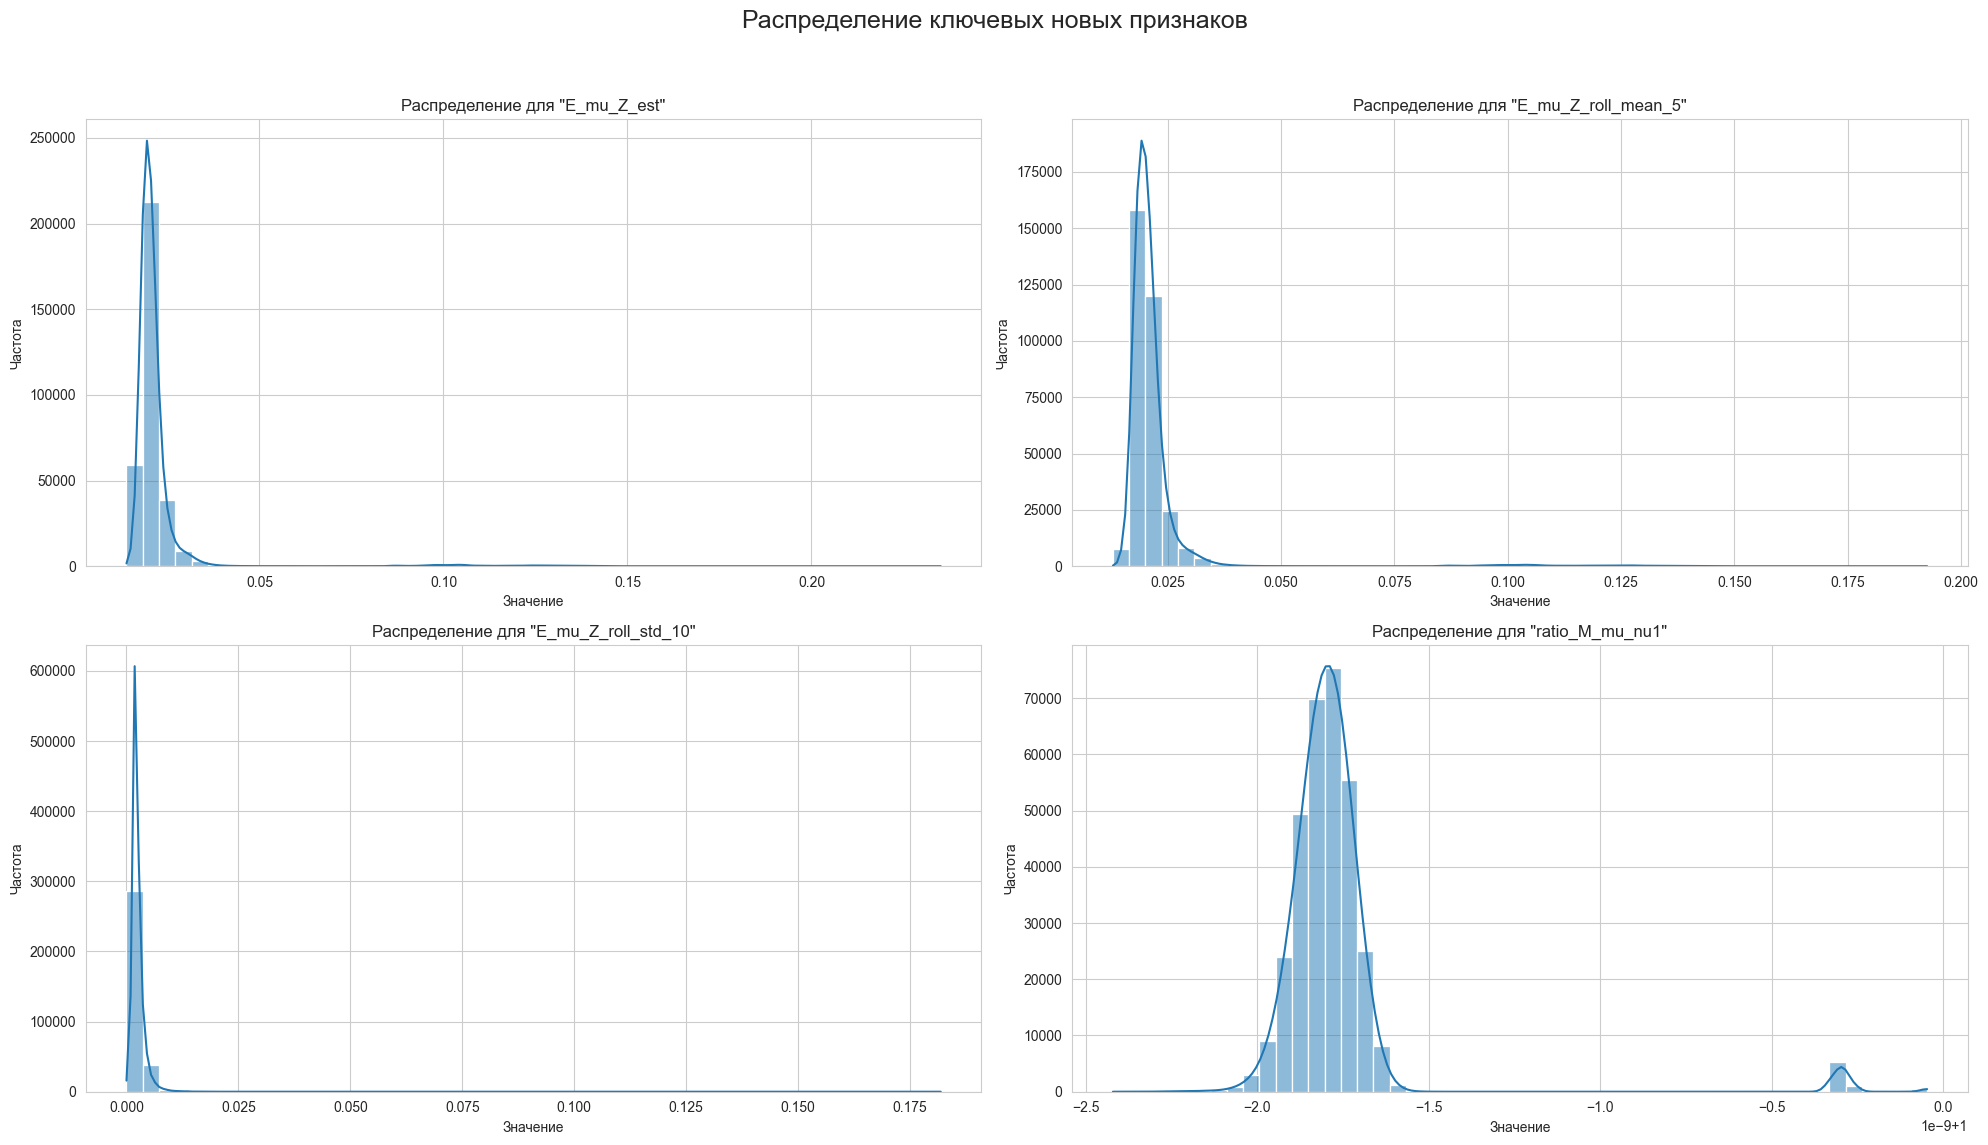

In [6]:
# ==============================================================================
# C.1. Изучение распределений
# ==============================================================================
if df_featured is not None:
    print("--- Анализ распределения ключевых сгенерированных признаков ---")
    
    # Выбираем признаки для анализа на основе нового топа корреляций.
    # Мы берем разные типы признаков, чтобы увидеть разные эффекты.
    features_to_analyze = [
        'E_mu_Z_est',              # Исходный топ-предиктор
        'E_mu_Z_roll_mean_5',      # Пример скользящего среднего (топ-2)
        'E_mu_Z_roll_std_10',      # Пример волатильности (чтобы проверить гипотезу)
        'ratio_M_mu_nu1'           # Пример признака-взаимодействия с положительной корреляцией
    ]
    
    # Создаем сетку графиков
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    fig.suptitle('Распределение ключевых новых признаков', fontsize=18)
    
    # `axes.flatten()` позволяет удобно итерироваться по сетке 2x2
    axes_flat = axes.flatten()
    
    for i, col in enumerate(features_to_analyze):
        # Работаем с данными без пропусков для корректного построения
        series_to_plot = df_featured[col].dropna()
        
        sns.histplot(series_to_plot, kde=True, ax=axes_flat[i], bins=50)
        axes_flat[i].set_title(f'Распределение для "{col}"')
        axes_flat[i].set_xlabel('Значение')
        axes_flat[i].set_ylabel('Частота')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")

--- Анализ мультиколлинеарности для 'семейства' признаков E_mu_Z_est ---

Выбраны следующие признаки для анализа:
['E_mu_Z_est', 'E_mu_Z_est', 'E_mu_Z_est_lag_1', 'E_mu_Z_est_lag_2', 'E_mu_Z_est_lag_3', 'E_mu_Z_est_lag_5', 'E_mu_Z_est_roll_mean_5', 'E_mu_Z_est_roll_std_5', 'E_mu_Z_est_roll_max_5', 'E_mu_Z_est_roll_mean_10', 'E_mu_Z_est_roll_std_10', 'E_mu_Z_est_roll_max_10']



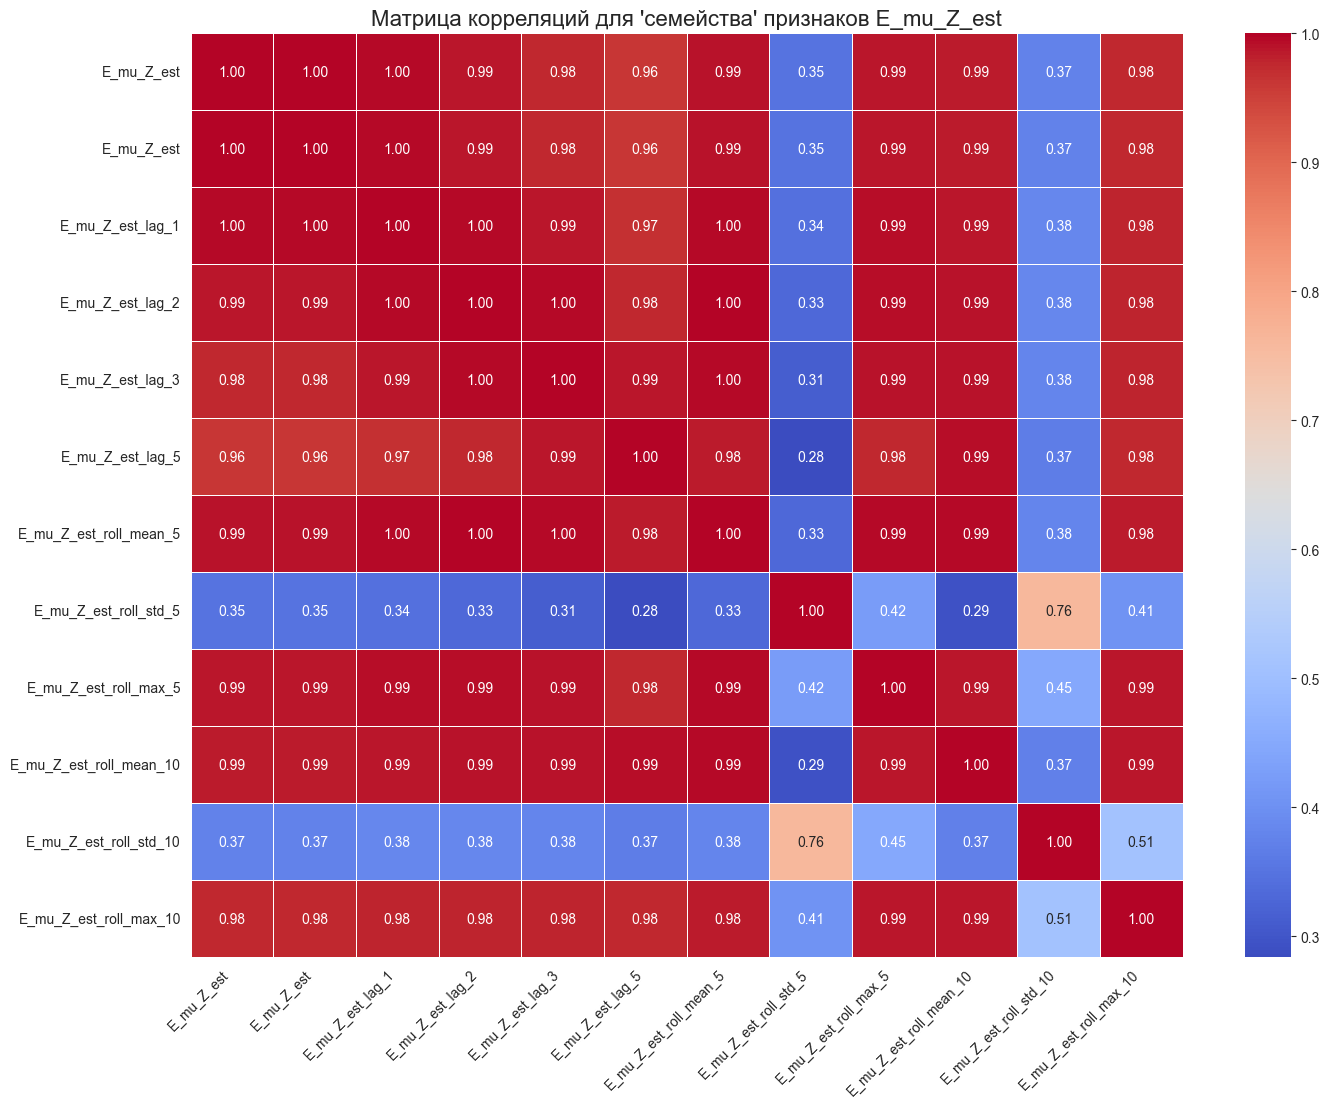

In [7]:
# ==============================================================================
# D.1. Анализ мультиколлинеарности "семейства" признаков
# ==============================================================================
if df_featured is not None:
    print("--- Анализ мультиколлинеарности для 'семейства' признаков E_mu_Z_est ---")
    
    # Собираем все новые признаки, которые были сгенерированы из 'E_mu_Z_est'
    family_cols_est = [col for col in df_featured.columns if 'E_mu_Z_est' in col]
    # Добавим для сравнения и исходный признак
    family_cols_est.insert(0, 'E_mu_Z_est')
    
    print(f"\nВыбраны следующие признаки для анализа:\n{family_cols_est}\n")
    
    # Рассчитываем матрицу корреляций для этой группы
    family_corr_matrix = df_featured[family_cols_est].corr()
    
    # Визуализируем матрицу
    plt.figure(figsize=(16, 12))
    sns.heatmap(family_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Матрица корреляций для 'семейства' признаков E_mu_Z_est", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ мультиколлинеарности для 'семейства' признаков s ---

Выбраны следующие признаки для анализа:
['s', 's_lag_1', 's_lag_2', 's_lag_3', 's_lag_5', 's_roll_mean_5', 's_roll_std_5', 's_roll_max_5', 's_roll_mean_10', 's_roll_std_10', 's_roll_max_10']



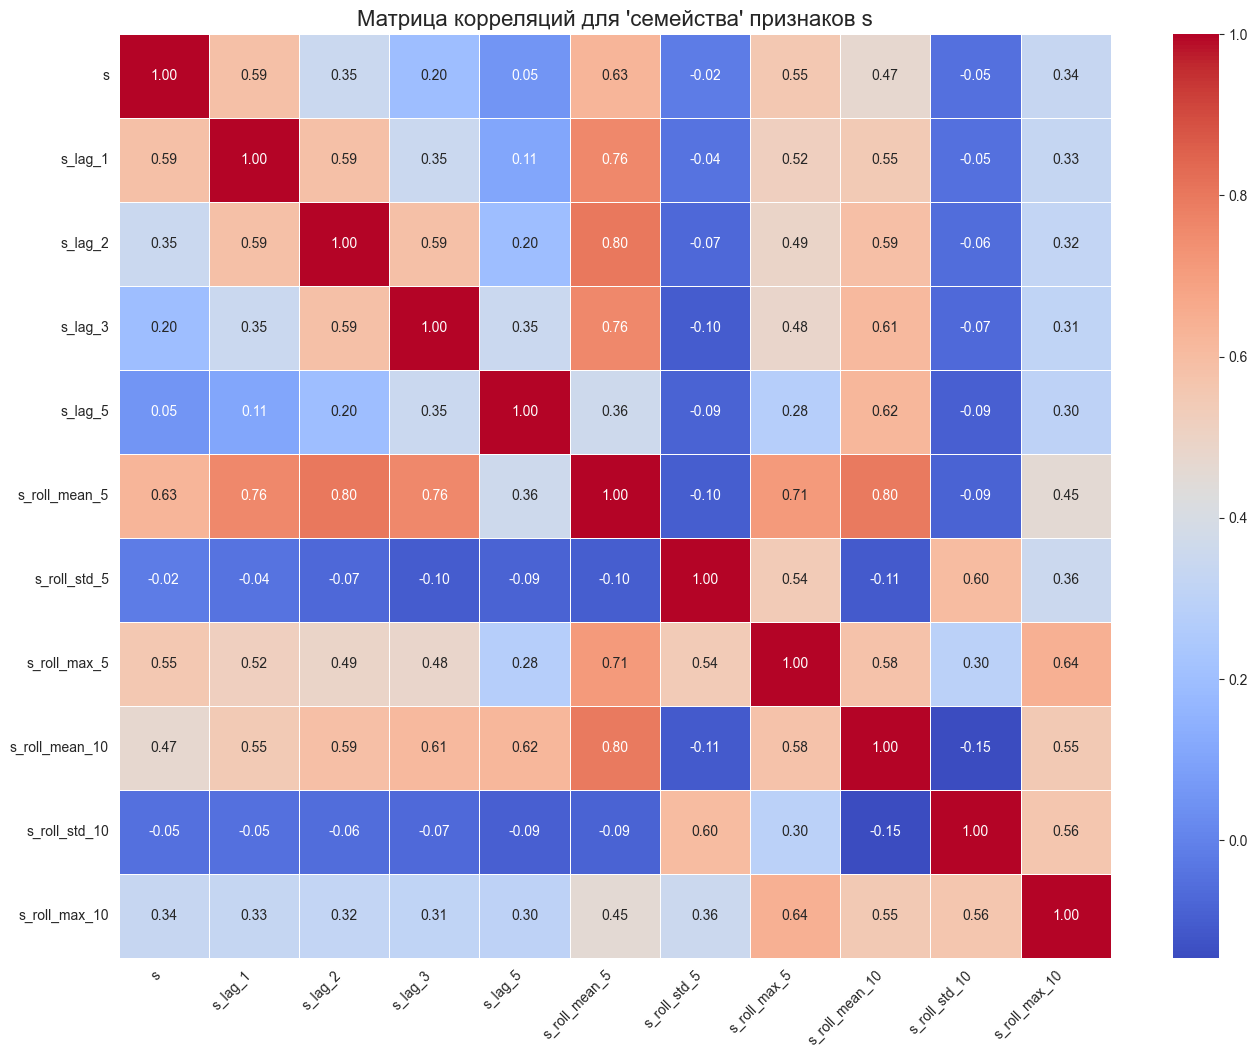

In [8]:
# ==============================================================================
# D.2. Анализ мультиколлинеарности для "семейства" признаков 's'
# ==============================================================================
if df_featured is not None:
    print("\n--- Анализ мультиколлинеарности для 'семейства' признаков s ---")
    
    # Собираем все признаки, которые были сгенерированы из 's'
    family_cols_s = [col for col in df_featured.columns if col == 's' or col.startswith('s_')]

    print(f"\nВыбраны следующие признаки для анализа:\n{family_cols_s}\n")
    
    # Рассчитываем и визуализируем матрицу корреляций
    family_corr_matrix_s = df_featured[family_cols_s].corr()
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(family_corr_matrix_s, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Матрица корреляций для 'семейства' признаков s", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")


--- Анализ мультиколлинеарности для 'семейства' признаков M_mu_XX ---

Выбраны следующие признаки для анализа:
['M_mu_XX', 'M_mu_XX_lag_1', 'M_mu_XX_lag_2', 'M_mu_XX_lag_3', 'M_mu_XX_lag_5', 'M_mu_XX_roll_mean_5', 'M_mu_XX_roll_std_5', 'M_mu_XX_roll_max_5', 'M_mu_XX_roll_mean_10', 'M_mu_XX_roll_std_10', 'M_mu_XX_roll_max_10']



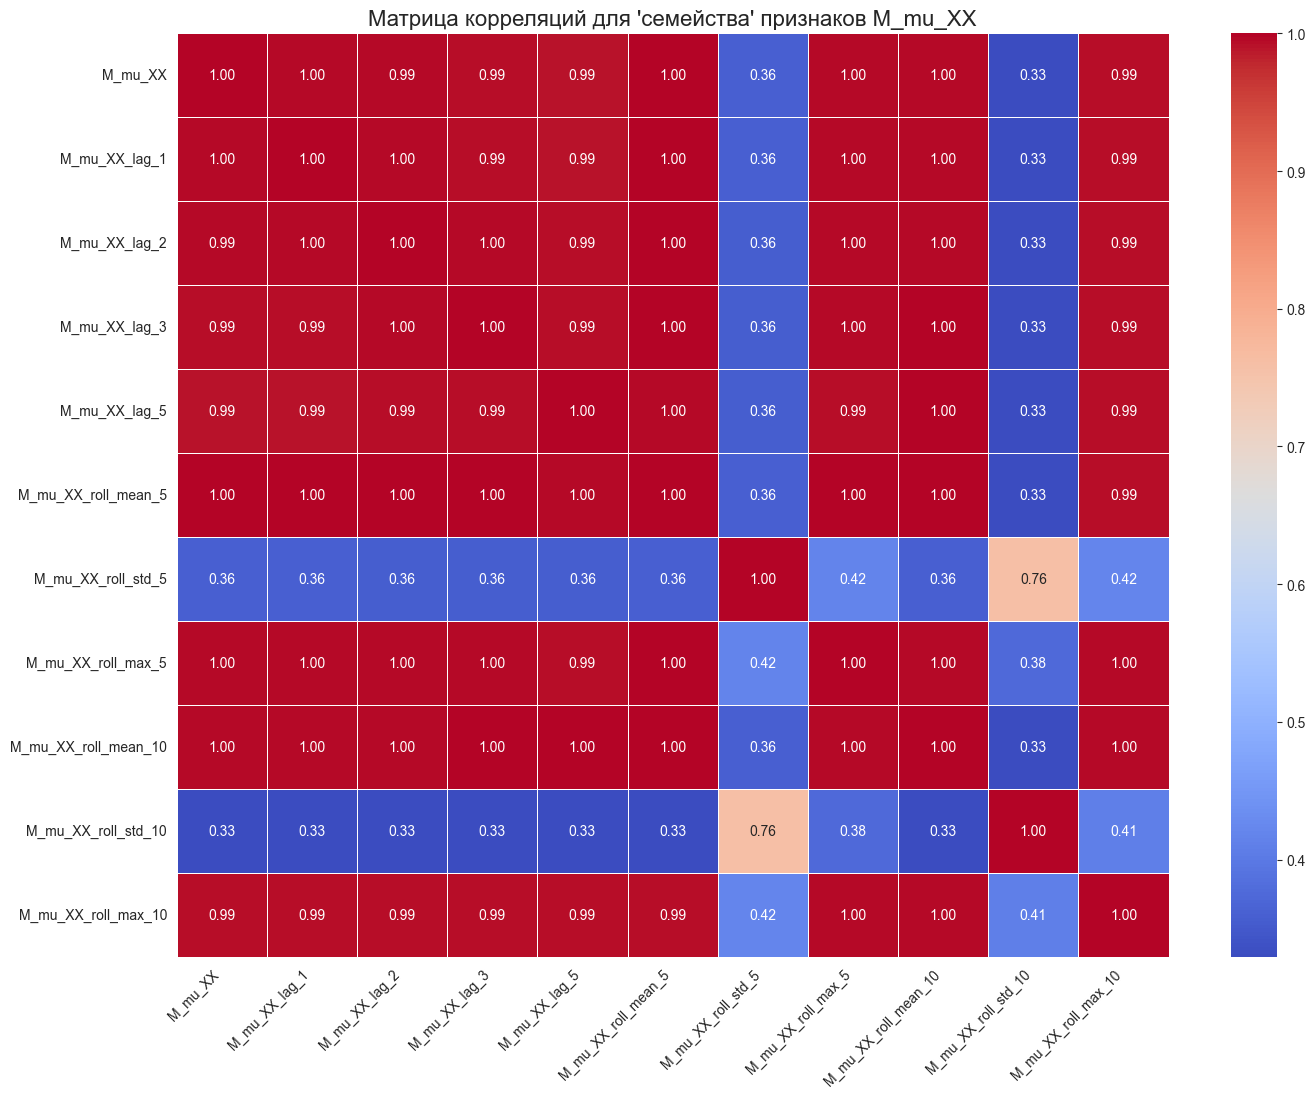

In [9]:
# ==============================================================================
# D.3. Анализ мультиколлинеарности для "семейства" признаков 'M_mu_XX'
# ==============================================================================
if df_featured is not None:
    print("\n--- Анализ мультиколлинеарности для 'семейства' признаков M_mu_XX ---")
    
    # Собираем все признаки, которые были сгенерированы из 'M_mu_XX'
    family_cols_m_mu_xx = [col for col in df_featured.columns if col == 'M_mu_XX' or col.startswith('M_mu_XX_')]

    print(f"\nВыбраны следующие признаки для анализа:\n{family_cols_m_mu_xx}\n")
    
    # Рассчитываем и визуализируем матрицу корреляций
    family_corr_matrix_m_mu_xx = df_featured[family_cols_m_mu_xx].corr()
    
    plt.figure(figsize=(16, 12))
    sns.heatmap(family_corr_matrix_m_mu_xx, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title("Матрица корреляций для 'семейства' признаков M_mu_XX", fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

else:
    print("Датафрейм не загружен. Пропустите выполнение этой ячейки.")